Importing Libraries required to process Geo- Spatial Data

In [2]:
import rasterio
import matplotlib.pyplot as plt
import os 
import numpy as np
import gc
import glob

Importing Deep Learning Libraries for PIX2PIX GAN

In [3]:
import tensorflow as tf
import keras

I0000 00:00:1782110952.787710    1378 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782110952.791514    1378 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782110953.245979    1378 pjrt_api.cc:96] PJRT_Api is set for device type gpu
I0000 00:00:1782110953.346237    1378 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782110954.855055    1378 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from d

Specifying Dataset directory and output directory for scene and patch generation  

In [25]:
dataset_DIR = "/home/avinash/ISRO/IR_to_RGB/Dataset_new"
output_DIR = "/home/avinash/ISRO/IR_to_RGB/Saved_Patches_new"
scene_folders = os.listdir(dataset_DIR)

In [26]:
os.makedirs(output_DIR, exist_ok=True)

Function to Normalize the values elimination outliers and scaling them between 0 and 1

In [27]:
def normalize(band):

    pLow = np.percentile(band, 2)
    pHigh = np.percentile(band, 98)

    band_Normalized = (band - pLow)/(pHigh- pLow)

    band_Clipped = np.clip(band_Normalized, 0, 1)

    return band_Clipped

Functioin to extract Patches from Scenes and save them as .npy files to output directory(Saved_Patches)

In [6]:
def extract_patches(IR, RED, GREEN, BLUE, scene_name, PATCH_SIZE = 256):
    H, W = IR.shape[0], IR.shape[1]
    patch_count = 0


    for row in range(0, H - PATCH_SIZE, PATCH_SIZE):
        for col in range(0, W - PATCH_SIZE, PATCH_SIZE):
            ir_patch = IR[row: row + PATCH_SIZE, col: col + PATCH_SIZE]

            if ir_patch.min() == 0:
                continue
            red_patch = RED[row: row + PATCH_SIZE, col: col + PATCH_SIZE]
            green_patch = GREEN[row: row + PATCH_SIZE, col: col + PATCH_SIZE]
            blue_patch = BLUE[row: row + PATCH_SIZE, col: col + PATCH_SIZE]

            rgb_patch = np.stack([red_patch, green_patch, blue_patch], axis=-1)
            os.makedirs(os.path.join(output_DIR, f"{scene_name}"),exist_ok=True)
            np.save(os.path.join(output_DIR, f"{scene_name}",f"ir_{patch_count}.npy"), arr=ir_patch)
            np.save(os.path.join(output_DIR, f"{scene_name}",f"rgb_{patch_count}.npy"), arr=rgb_patch)
            patch_count += 1
    return patch_count



In [47]:
def extract_patches_multiband(IR, NIR, SWIR1, SWIR2, RED, GREEN, BLUE, scene_name, PATCH_SIZE = 256):
    H, W = IR.shape[0], IR.shape[1]
    patch_count = 0


    for row in range(0, H - PATCH_SIZE, PATCH_SIZE):
        for col in range(0, W - PATCH_SIZE, PATCH_SIZE):
            ir_patch = IR[row: row + PATCH_SIZE, col: col + PATCH_SIZE]

            if ir_patch.min() == 0:
                continue
            red_patch = RED[row: row + PATCH_SIZE, col: col + PATCH_SIZE]
            green_patch = GREEN[row: row + PATCH_SIZE, col: col + PATCH_SIZE]
            blue_patch = BLUE[row: row + PATCH_SIZE, col: col + PATCH_SIZE]
            blue_patch = BLUE[row: row + PATCH_SIZE, col: col + PATCH_SIZE]
            nir_patch = NIR[row: row + PATCH_SIZE, col: col + PATCH_SIZE]
            swir_1_patch = SWIR1[row: row + PATCH_SIZE, col: col + PATCH_SIZE]
            swir_2_patch = SWIR2[row: row + PATCH_SIZE, col: col + PATCH_SIZE]

            input_patch = np.stack([ir_patch, nir_patch, swir_1_patch, swir_2_patch], axis=-1)


            rgb_patch = np.stack([red_patch, green_patch, blue_patch], axis=-1)
            os.makedirs(os.path.join(output_DIR, f"{scene_name}"),exist_ok=True)
            np.save(os.path.join(output_DIR, f"{scene_name}",f"input_{patch_count}.npy"), arr=input_patch)
            np.save(os.path.join(output_DIR, f"{scene_name}",f"rgb_{patch_count}.npy"), arr=rgb_patch)
            patch_count += 1
    return patch_count



Iterating through each scene, 
Accessing band of each scene and applying normalization, 
Extracting Patches from all the scenes

In [48]:
total_saved_patches = 0

for scene in scene_folders:
    print(f"Extracting from scene: ", scene)
    scene_path = os.path.join(dataset_DIR, scene)

    with rasterio.open(f'{scene_path}/lwir11.tif') as src:
        IR = src.read(1)
    with rasterio.open(f'{scene_path}/red.tif') as src:
        RED = src.read(1)
    with rasterio.open(f'{scene_path}/green.tif') as src:
        GREEN = src.read(1)
    with rasterio.open(f'{scene_path}/blue.tif') as src:
        BLUE = src.read(1)
    with rasterio.open(f'{scene_path}/nir08.tif') as src:
        NIR = src.read(1)
    with rasterio.open(f'{scene_path}/swir16.tif') as src:
        SWIR1 = src.read(1)
    with rasterio.open(f'{scene_path}/swir22.tif') as src:
        SWIR2 = src.read(1)
    
    
    redNorm = normalize(RED)
    greenNorm = normalize(GREEN)
    blueNorm = normalize(BLUE)
    irNorm = normalize(IR)
    nirnorm = normalize(NIR)
    swir1_norm = normalize(SWIR1)
    swir2_norm = normalize(SWIR2)

    saved_count = extract_patches_multiband(irNorm,nirnorm, swir1_norm, swir2_norm, redNorm, greenNorm, blueNorm, scene)
    total_saved_patches += saved_count

    del IR, RED, GREEN, BLUE
    del redNorm, greenNorm, blueNorm, irNorm
    gc.collect()


print("Total pairs across all scenes:", total_saved_patches)


Extracting from scene:  sample_1
Total pairs across all scenes: 563


Collecting paths of each .npy file in pairs faster pair access

In [49]:
def collect_patch_paths(root_dir):
    sample_files = os.listdir(root_dir)
    pairs = []

    for sample in sample_files:
        sample_path = os.path.join(root_dir, sample)
        input_files = glob.glob(os.path.join(sample_path, "input_*.npy"))

        for input_path in input_files:
            rgb_path = input_path.replace("input_", "rgb_")

            pairs.append((input_path, rgb_path))

    return pairs

In [50]:
pairs = collect_patch_paths("/home/avinash/ISRO/IR_to_RGB/Saved_Patches_new")
print("Total pairs:", len(pairs))
print(pairs[0])

Total pairs: 563
('/home/avinash/ISRO/IR_to_RGB/Saved_Patches_new/sample_1/input_439.npy', '/home/avinash/ISRO/IR_to_RGB/Saved_Patches_new/sample_1/rgb_439.npy')


In [51]:
x = np.load('/home/avinash/ISRO/IR_to_RGB/Saved_Patches_new/sample_1/input_0.npy')

In [52]:
x.shape

(256, 256, 4)

Creating a generator function that yields a IR: RGB pair

In [55]:
def data_generator(pairs):
    for ir_pair, rgb_path in pairs:
        ir = np.load(ir_pair)
        # ir = np.expand_dims(ir, axis=-1)
        rgb = np.load(rgb_path)

        yield ir, rgb

In [56]:
gen = data_generator(pairs)
ir_sample, rgb_sample = next(gen)
print(ir_sample.shape, rgb_sample.shape)

(256, 256, 4) (256, 256, 3)


Making the Dataset function to create the dataset for pairs that will be fed to the model

In [57]:
def make_dataset(pairs, batch_size=4):
    dataset = tf.data.Dataset.from_generator(
        lambda: data_generator(pairs),
        output_signature=(
            tf.TensorSpec(shape=(256, 256, 1)),
            tf.TensorSpec(shape=(256, 256, 3))
        )
    )
    dataset = dataset.shuffle(buffer_size=500)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)    
    return dataset

Train_ds is the full dataset containing all the 11262 samples

In [58]:
train_ds = make_dataset(pairs, batch_size=8)



In [59]:
tf.keras.backend.clear_session()

Setting mixed precision to utilize 5070tensor cores for Training

In [60]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

U-Net Architecture

The downsample block in the U-Net encoder section consists of a Conv2D, batch Normalization and Leaky ReLU setup 

In [61]:
def downsample_block_en(filters, size=4):
    block = tf.keras.Sequential()
    block.add(tf.keras.layers.Conv2D(filters, size, strides=2, padding='same'))
    block.add(tf.keras.layers.BatchNormalization())
    block.add(tf.keras.layers.LeakyReLU())
    return block


In [62]:
block = downsample_block_en(64)
test_input = tf.random.normal([1, 256, 256, 1])  # fake IR batch of 1
output = block(test_input)
print(output.shape)

(1, 128, 128, 64)


E0000 00:00:1782119951.476793    1378 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


Function to build the entire Encoder Section 

In [63]:
def build_encoder():
    filter_list = [64, 128, 256, 512, 512, 512, 512, 512]
    blocks = []
    for filter in filter_list:
        blocks.append(downsample_block_en(filter))

    return blocks


The decoder block consists of UpSampling2D and Conv2D with Batch Normalization and LeakyReLU 

Earlier attempt to produce model with TransposeConv2D failed due to generated image havinh CheckBoard artifact

In [64]:
def decoder_block(filters, dropout, size = 4):
    block = tf.keras.Sequential()
    block.add(tf.keras.layers.UpSampling2D(size=2))
    block.add(tf.keras.layers.Conv2D(filters, size, strides=1, padding='same'))
    block.add(tf.keras.layers.BatchNormalization())
    if dropout:
        block.add(tf.keras.layers.Dropout(0.5))
    block.add(tf.keras.layers.ReLU())

    return block

In [65]:
def build_decoder():
    filter_list = [512, 512, 512, 512, 256, 128, 64]
    dropout_list = [True, True, True, False, False, False, False]  
    blocks = []
    for filter, dropout in zip(filter_list, dropout_list):
        blocks.append(decoder_block(filter, dropout))
    return blocks

Building the full U-Net architecture with skips connection between encoder and decoder

Generator function

In [66]:
def build_generator():
    tf.keras.backend.clear_session()

    inputs = tf.keras.Input(shape=( 256, 256 ,4))

    x = inputs
    skip_outputs = []
    
    encoder_blocks = build_encoder()


    for i, block in enumerate(encoder_blocks):
        x = block(x)
        print(f"Shape of input after {i+1} block: {x.shape}")
        skip_outputs.append(x)
    
    print("No of skip outputs saved: ", len(skip_outputs))
    for i, s in enumerate(skip_outputs):
        print(f"skip {i}: {s.shape}")
    
    skips_for_decoder = list(reversed(skip_outputs[:-1]))
    decoder_blocks = build_decoder()
    for idx, (block, skip) in enumerate(zip(decoder_blocks, skips_for_decoder)):
        x = block(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        print(f"Shape after Up-block {idx+1} (with concat): {x.shape}")

    final_layer = tf.keras.Sequential([
    tf.keras.layers.UpSampling2D(size=2),
    tf.keras.layers.Conv2D(3, 4, strides=1, padding='same', activation='sigmoid')
])
    outputs = final_layer(x)
    print("Final Output Shape: ",outputs.shape)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

generator = build_generator()
print("/n")
generator.summary()



Shape of input after 1 block: (None, 128, 128, 64)
Shape of input after 2 block: (None, 64, 64, 128)
Shape of input after 3 block: (None, 32, 32, 256)
Shape of input after 4 block: (None, 16, 16, 512)
Shape of input after 5 block: (None, 8, 8, 512)
Shape of input after 6 block: (None, 4, 4, 512)
Shape of input after 7 block: (None, 2, 2, 512)
Shape of input after 8 block: (None, 1, 1, 512)
No of skip outputs saved:  8
skip 0: (None, 128, 128, 64)
skip 1: (None, 64, 64, 128)
skip 2: (None, 32, 32, 256)
skip 3: (None, 16, 16, 512)
skip 4: (None, 8, 8, 512)
skip 5: (None, 4, 4, 512)
skip 6: (None, 2, 2, 512)
skip 7: (None, 1, 1, 512)
Shape after Up-block 1 (with concat): (None, 2, 2, 1024)
Shape after Up-block 2 (with concat): (None, 4, 4, 1024)
Shape after Up-block 3 (with concat): (None, 8, 8, 1024)
Shape after Up-block 4 (with concat): (None, 16, 16, 1024)
Shape after Up-block 5 (with concat): (None, 32, 32, 512)
Shape after Up-block 6 (with concat): (None, 64, 64, 256)
Shape after Up-

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │      4,416 │ input_layer[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 64,    │    131,712 │ sequential[0][0]  │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 32,    │    525,568 │ sequential_1[0][… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 16, 16,    │  2,099,712 │ sequential_2[0][… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 8, 8, 512) │  4,196,864 │ sequential_3[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 4, 4, 512) │  4,196,864 │ sequential_4[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 2, 2, 512) │  4,196,864 │ sequential_5[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 1, 1, 512) │  4,196,864 │ sequential_6[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 2, 2, 512) │  4,196,864 │ sequential_7[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2, 2,      │          0 │ sequential_8[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 4, 4, 512) │  8,391,168 │ concatenate[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 4, 4,      │          0 │ sequential_9[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_10       │ (None, 8, 8, 512) │  8,391,168 │ concatenate_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8,      │          0 │ sequential_10[0]… │
│ (Concatenate)       │ 1024)             │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_11       │ (None, 16, 16,    │  8,391,168 │ concatenate_2[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ sequential_11[0]

 Total params: 54,432,643 (207.64 MB)

 Trainable params: 54,421,635 (207.60 MB)

 Non-trainable params: 11,008 (43.00 KB)

PatchGAN


Down Sample block of patch GAn is same as encoder block of U-Net with the option of not applying Batch Normalization for 1st few layers


In [67]:
def downsample_block(filters, strides, ADD_BatchNorm = True):
    block = tf.keras.Sequential()
    block.add(tf.keras.layers.Conv2D(filters, 4, strides, padding='same'))
    if ADD_BatchNorm:
        block.add(tf.keras.layers.BatchNormalization())
    block.add(tf.keras.layers.LeakyReLU())

    return block

Discriminator Function

In [68]:

def build_discriminator():
   
    
    ir_input = tf.keras.Input((256, 256, 1))
    rgb_input = tf.keras.Input((256, 256, 3))
    x = tf.keras.layers.Concatenate()([ir_input, rgb_input])
    x = downsample_block(64, 2, False)(x)
    x = downsample_block(128, 2)(x)
    x = downsample_block(256, 2)(x)
    x = downsample_block(512, 1)(x)
    
    final_layer = tf.keras.layers.Conv2D(1, 4, 1, 'same')

    outputs = final_layer(x)
    
    model = tf.keras.Model(inputs=[ir_input, rgb_input], outputs=outputs)
    return model



In [69]:
discriminator = build_discriminator()
discriminator.summary()

Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 256, 256,  │          0 │ input_layer_17[0… │
│ (Concatenate)       │ 4)                │            │ input_layer_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_16       │ (None, 128, 128,  │      4,160 │ concatenate_7[0]… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_17       │ (None, 64, 64,    │    131,712 │ sequential_16[0]… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_18       │ (None, 32, 32,    │    525,568 │ sequential_17[0]… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_19       │ (None, 32, 32,    │  2,099,712 │ sequential_18[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32, 1) │      8,193 │ sequential_19[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,769,345 (10.56 MB)

 Trainable params: 2,767,553 (10.56 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [70]:
test_ir = tf.random.normal([4, 256, 256, 1])
test_rgb = tf.random.normal([4, 256, 256, 3])
output = discriminator([test_ir, test_rgb])
print("Output shape:", output.shape)

Output shape: (4, 32, 32, 1)


Discriminator Loss


In [71]:
loss_object = tf.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = loss_object(tf.ones_like(real_output) * 0.9, real_output)
    fake_loss = loss_object(tf.ones_like(fake_output), fake_output)

    total_loss = real_loss + fake_loss
    return total_loss

Generator Loss

In [72]:
LAMBDA_L1 = 100
LAMBDA_SSIM = 10

In [73]:
def generator_loss(disc_fake_output, generated_rgb, target_rgb):
    adverserial_loss = loss_object(tf.ones_like(disc_fake_output), disc_fake_output)

    L1_loss = tf.reduce_mean(tf.abs(generated_rgb - target_rgb))
    # SSIM_loss =1 - tf.reduce_mean( tf.image.ssim(generated_rgb, target_rgb, max_val=1.0))
    total_loss = adverserial_loss + (LAMBDA_L1 * L1_loss) 

    return total_loss

Loss needs to be scaled due to mixed_precision setting

In [74]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

generator_optimizer = tf.keras.mixed_precision.LossScaleOptimizer(generator_optimizer)
discriminator_optimizer = tf.keras.mixed_precision.LossScaleOptimizer(discriminator_optimizer)

Training Loop function

In [75]:
@tf.function
def training_loop(ir_batch, real_rgb_batch):

    with tf.GradientTape() as disc_tape, tf.GradientTape() as gen_tape:

        fake_rgb = generator(ir_batch, training=True)

        disc_real_output = discriminator([ir_batch, real_rgb_batch], training=True)
        disc_fake_output = discriminator([ir_batch, fake_rgb], training=True)

        gen_loss = generator_loss(disc_fake_output, fake_rgb, real_rgb_batch)
        disc_loss = discriminator_loss(disc_real_output, disc_fake_output)

        scaled_gen_loss = generator_optimizer.scale_loss(gen_loss)
        scaled_disc_loss = discriminator_optimizer.scale_loss(disc_loss)

    scaled_generator_gradients = gen_tape.gradient(scaled_gen_loss, generator.trainable_variables)
    scaled_discriminator_gradients = disc_tape.gradient(scaled_disc_loss, discriminator.trainable_variables)

    

    generator_optimizer.apply_gradients(zip(scaled_generator_gradients, generator.trainable_variables ))
    discriminator_optimizer.apply_gradients(zip(scaled_discriminator_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [27]:
import random

subset_pairs = random.sample(pairs, 2500)
train_ds_small = make_dataset(subset_pairs, 8)

In [28]:
import time
from tqdm import tqdm

In [76]:
import datetime

log_dir = "/home/avinash/ISRO/IR_to_RGB/logs/L100-20EP-4IP=" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = tf.summary.create_file_writer(log_dir)

In [77]:
def compute_metrics(generated, target):
    psnr = tf.reduce_mean(tf.image.psnr(generated, target, max_val=1.0))
    ssim = tf.reduce_mean(tf.image.ssim(generated, target, max_val=1.0))
    return psnr, ssim

In [80]:
checkpoint_dir = '/home/avinash/ISRO/IR_to_RGB/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

def train(dataset, epochs, save_every=10):
    
    for epoch in range(epochs):
        print("Starting epoch:", epoch)
        start = time.time()
        gc.collect()

        
        for ir_batch, rgb_batch in dataset:
            gen_loss, disc_loss = training_loop(ir_batch, rgb_batch)

          

        fake_rgb = generator(ir_batch, training=False)

        psnr, ssim = compute_metrics(fake_rgb, rgb_batch)
        
        with summary_writer.as_default():
            tf.summary.scalar('gen_loss', gen_loss, step=epoch)
            tf.summary.scalar('disc_loss', disc_loss, step=epoch)
            tf.summary.scalar('psnr', psnr, step=epoch)
            tf.summary.scalar('ssim', ssim, step=epoch)

        
        print(f"Epoch {epoch+1}/{epochs} — Gen loss: {gen_loss:.4f}, Disc loss: {disc_loss:.4f}, Time: {time.time()-start:.1f}s")
        
        if (epoch + 1) % save_every == 0:
            generator.save_weights(f'{checkpoint_dir}/generator_epoch_{epoch+1}.weights.h5')
            print(f"  → Saved checkpoint at epoch {epoch+1}")

In [31]:
train_ds_16 = make_dataset(pairs, 16)

EPOCH 10 - 30 LAMBDA 100

In [39]:
# # Rebuild dataset at batch_size=16
# train_ds_16 = make_dataset(pairs, batch_size=16)

# # Run just 2 epochs, watching closely
# train(train_ds_16, epochs=90, save_every=10)

EPOCH 1 - 30 LAMBDA 80

In [38]:
tf.keras.backend.clear_session()

In [81]:
LAMBDA_L1 = 100

In [84]:
train(train_ds_16, epochs=70, save_every=10)

Starting epoch: 0
Epoch 1/70 — Gen loss: 3.5379, Disc loss: 0.3253, Time: 280.5s
Starting epoch: 1
Epoch 2/70 — Gen loss: 3.6733, Disc loss: 0.3254, Time: 282.3s
Starting epoch: 2
Epoch 3/70 — Gen loss: 2.9384, Disc loss: 0.3252, Time: 282.5s
Starting epoch: 3
Epoch 4/70 — Gen loss: 3.2830, Disc loss: 0.3255, Time: 281.4s
Starting epoch: 4
Epoch 5/70 — Gen loss: 3.7002, Disc loss: 0.3252, Time: 282.0s
Starting epoch: 5
Epoch 6/70 — Gen loss: 2.9315, Disc loss: 0.3253, Time: 281.8s
Starting epoch: 6
Epoch 7/70 — Gen loss: 3.0904, Disc loss: 0.3252, Time: 283.9s
Starting epoch: 7
Epoch 8/70 — Gen loss: 3.2329, Disc loss: 0.3253, Time: 283.0s
Starting epoch: 8
Epoch 9/70 — Gen loss: 3.0190, Disc loss: 0.3253, Time: 282.2s
Starting epoch: 9
Epoch 10/70 — Gen loss: 3.2453, Disc loss: 0.3252, Time: 283.0s
  → Saved checkpoint at epoch 10
Starting epoch: 10
Epoch 11/70 — Gen loss: 3.0212, Disc loss: 0.3261, Time: 282.8s
Starting epoch: 11
Epoch 12/70 — Gen loss: 3.1636, Disc loss: 0.3252, Tim

In [21]:
import matplotlib.pyplot as plt

def show_sample(generator, ir_patch, real_rgb_patch):
    # ir_patch shape: (256, 256, 1) -> need to add batch dimension
    ir_input = tf.expand_dims(ir_patch, axis=0)   # (1, 256, 256, 1)
    
    fake_rgb = generator(ir_input, training=False)   # (1, 256, 256, 3)
    fake_rgb = fake_rgb[0]   # remove batch dimension -> (256, 256, 3)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(ir_patch[:, :, 0], cmap='gray')
    axes[0].set_title("Input IR")
    axes[0].axis('off')
    
    axes[1].imshow(fake_rgb.numpy())
    axes[1].set_title("Generated RGB")
    axes[1].axis('off')
    
    axes[2].imshow(real_rgb_patch.numpy())
    axes[2].set_title("Ground Truth RGB")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

    print(compute_metrics(fake_rgb, real_rgb_patch))

In [19]:
generator.load_weights('/home/avinash/ISRO/IR_to_RGB/checkpoints/generator_epoch_70.weights.h5')

In [22]:
show_sample(generator ,ir_batch[0], rgb_batch[0])

NameError: name 'ir_batch' is not defined

In [67]:
import numpy as np

# Sample a chunk of real RGB patches across different scenes
sample_indices = list(range(0, len(pairs), len(pairs)//50))[:50]  # spread across dataset

variances = []
for idx in sample_indices:
    rgb_path = pairs[idx][1]
    rgb = np.load(rgb_path)
    variances.append(rgb.std())  # std deviation = spread of pixel values

print(f"Mean color std across {len(variances)} patches: {np.mean(variances):.4f}")
print(f"Min std: {np.min(variances):.4f}")
print(f"Max std: {np.max(variances):.4f}")
print(f"Median std: {np.median(variances):.4f}")

Mean color std across 50 patches: 0.0596
Min std: 0.0347
Max std: 0.0930
Median std: 0.0572


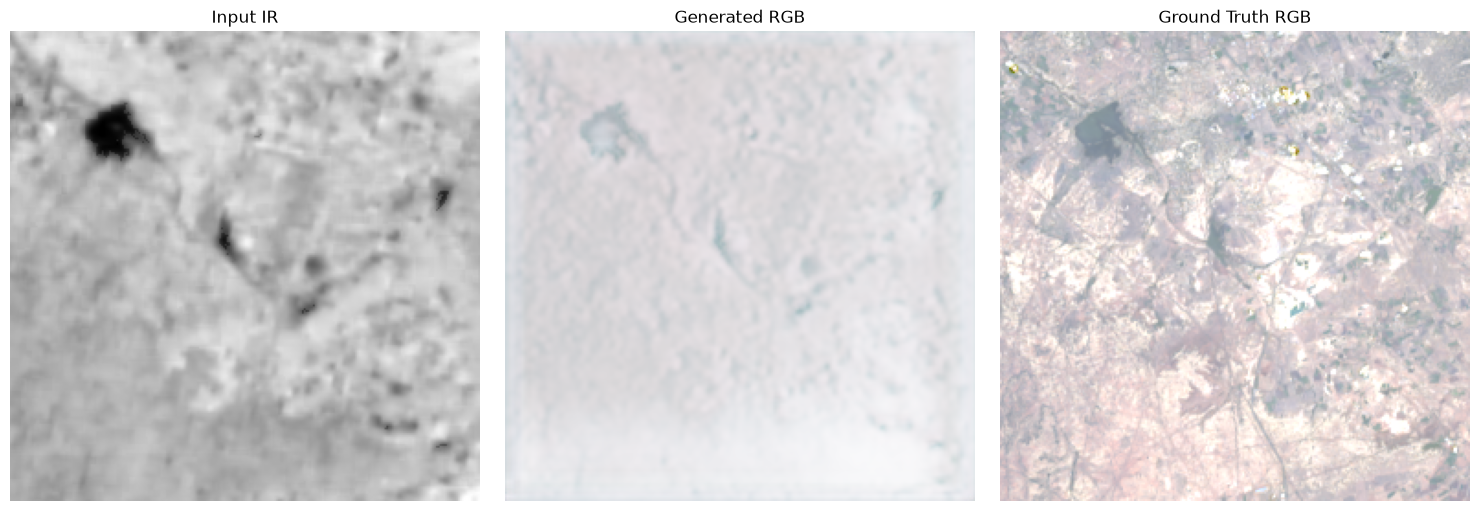

(<tf.Tensor: shape=(), dtype=float32, numpy=19.507701873779297>, <tf.Tensor: shape=(), dtype=float32, numpy=0.3561237156391144>)


In [24]:
for ir_batch, rgb_batch in train_ds.take(1):
    show_sample(generator, ir_batch[0], rgb_batch[0])
    break

In [1]:
generator.load_weights('/home/avinash/ISRO/IR_to_RGB/checkpoints/generator_epoch_70.weights.h5')

NameError: name 'generator' is not defined

In [73]:
import rasterio
import numpy as np

def normalize_with_contrast_boost(band, lo=1, hi=99, gamma=0.8):
    p_low = np.percentile(band, lo)
    p_high = np.percentile(band, hi)
    stretched = (band - p_low) / (p_high - p_low + 1e-8)
    stretched = np.clip(stretched, 0, 1)
    boosted = np.power(stretched, gamma)
    return boosted

# test on one scene's RGB bands
test_scene = scene_folders[0]  # or any specific scene path
with rasterio.open(f'{dataset_DIR}/{test_scene}/red.tif') as src:
    red = src.read(1)
with rasterio.open(f'{dataset_DIR}/{test_scene}/green.tif') as src:
    green = src.read(1)
with rasterio.open(f'{dataset_DIR}/{test_scene}/blue.tif') as src:
    blue = src.read(1)

# compare old vs new normalization
red_old = normalize(red)            # your original function
red_new = normalize_with_contrast_boost(red)

print(f"OLD normalize std: {red_old.std():.4f}")
print(f"NEW normalize std: {red_new.std():.4f}")

OLD normalize std: 0.3475
NEW normalize std: 0.3548


In [ ]:
import matplotlib.pyplot as plt

green_new = normalize_with_contrast_boost(green)
blue_new = normalize_with_contrast_boost(blue)
rgb_new = np.stack([red_new, green_new, blue_new], axis=-1)

red_old_full = normalize(red)
green_old_full = normalize(green)
blue_old_full = normalize(blue)
rgb_old = np.stack([red_old_full, green_old_full, blue_old_full], axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(rgb_old)
axes[0].set_title(f"OLD normalize (std={rgb_old.std():.4f})")
axes[0].axis('off')

axes[1].imshow(rgb_new)
axes[1].set_title(f"NEW normalize (std={rgb_new.std():.4f})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

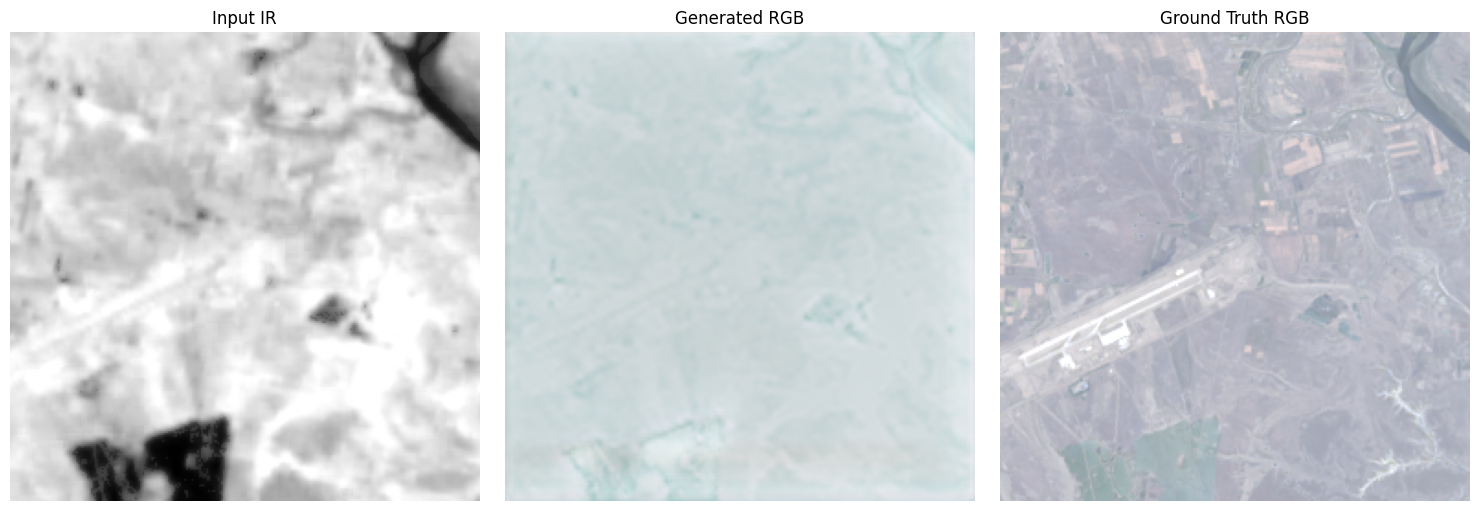

(<tf.Tensor: shape=(), dtype=float32, numpy=18.99701690673828>, <tf.Tensor: shape=(), dtype=float32, numpy=0.6939842104911804>)


In [76]:
for ir_batch, rgb_batch in train_ds.take(5):
    show_sample(generator, ir_batch[0], rgb_batch[0])
    break